In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### ANN

In [2]:
class Layer:
    def __init__(self, num_of_neurons, input_size, activation_type):
        self.weight = np.random.randn(input_size, num_of_neurons) * 0.01
        self.bias = np.random.randn(1, num_of_neurons)
        self.activation_function = Layer.activation_map[activation_type][0].__get__(self)
        self.activationGr = Layer.activation_map[activation_type][1].__get__(self)
    def Forward(self, X):
        p = (X @ self.weight) + self.bias
        z = self.activation_function(p)
        return z
    
    def Forward_with_caching(self, X):
        self.Zl_1 = X
        self.Pl = (X @ self.weight) + self.bias # Pre_activation
        self.Zl = self.activation_function(self.Pl) # After_activation
        return self.Zl
    
    def Update_weights(self, dZ, alpha):
        m = self.Zl_1.shape[0] # m --> Batch size

        dZ = np.clip(dZ, -5, 5) # dz --> errorGr
        dP = dZ * self.activationGr()
        dW = (self.Zl_1.T @ dP) / m
        dB = np.sum(dP, axis=0, keepdims=True) / m
        dZ_prev = dP @ self.weight.T

        # update
        self.weight -= alpha * dW
        self.bias -= alpha * dB

        return dZ_prev
    

    def Sigmoid(self, X):
        return 1 / (1 + np.exp(-1 * X)) 
    
    def SigmoidGr(self):
        return self.Zl * (1 - self.Zl)

    def Relu(self, X):
        return (X > 0) * X
    
    def ReluGr(self):
        return (self.Pl > 0).astype(float)

    def Linear(self, X):
        return X
    
    def LinearGr(self):
        return np.ones_like(self.Zl)

    activation_map = {
        1: (Sigmoid, SigmoidGr), 
        2: (Relu, ReluGr), 
        3: (Linear, LinearGr)
    }

In [3]:
class ANN:
    Sigmoid = 1
    Relu = 2
    Linear = 3

    def __init__(self, input_size):
        self.layers = []
        self.input_size = input_size

    def add_layer(self, num_of_neurons, activation_type):
        self.layers.append(Layer(num_of_neurons=num_of_neurons, input_size=self.input_size, activation_type=activation_type))
        self.input_size = num_of_neurons

    def Predict(self, X):
        out = X
        for layer in self.layers:
            out = layer.Forward(out)
        return out
    def Backprop(self, X, y, alpha):
        y = y.reshape((-1, 1))
        yEstimate = X
        for layer in self.layers:
            yEstimate = layer.Forward_with_caching(yEstimate)
        
        errorGr = yEstimate - y

        for layer in reversed(self.layers):
            errorGr = layer.Update_weights(errorGr, alpha)
        

### Dataset

In [4]:
df = pd.read_csv(r"E:\my_files\Lectures\Level 2\2nd term\Computational intelligence\data.csv")
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


### Checking Data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

#### Null values

In [6]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [7]:
df = df.drop('Unnamed: 32', axis=1)

#### Duplicated values

In [8]:
print(f'Number of duplicated = {df.duplicated().sum()}')

Number of duplicated = 0


#### Infinit values

In [9]:
df.isin([np.inf, -np.inf]).sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

### Splitting and encoding

#### Splitting the target

In [10]:
X = df.drop(['id', 'diagnosis'], axis=1)
y = df['diagnosis']

In [11]:
y.value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

#### Encoding the target

In [12]:
encoder = {"M" :1, "B" :0}
y = y.map(encoder)
y

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64

#### Train test split

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f'X_train shape --> {X_train.shape}')
print(f'X_test shape --> {X_test.shape}')
print(f'y_train shape --> {y_train.shape}')
print(f'y_test shape --> {y_test.shape}')

X_train shape --> (426, 30)
X_test shape --> (143, 30)
y_train shape --> (426,)
y_test shape --> (143,)


#### Checking data after splitting

In [14]:
print("NaN in X_train:", np.isnan(X_train).any())
print("NaN in y_train:", np.isnan(y_train).any())
print("NaN in X_test:", np.isnan(X_test).any())
print("Nan in y_test:", np.isnan(y_test).any())

NaN in X_train: radius_mean                False
texture_mean               False
perimeter_mean             False
area_mean                  False
smoothness_mean            False
compactness_mean           False
concavity_mean             False
concave points_mean        False
symmetry_mean              False
fractal_dimension_mean     False
radius_se                  False
texture_se                 False
perimeter_se               False
area_se                    False
smoothness_se              False
compactness_se             False
concavity_se               False
concave points_se          False
symmetry_se                False
fractal_dimension_se       False
radius_worst               False
texture_worst              False
perimeter_worst            False
area_worst                 False
smoothness_worst           False
compactness_worst          False
concavity_worst            False
concave points_worst       False
symmetry_worst             False
fractal_dimension_worst    

In [15]:
X_train = np.nan_to_num(X_train)
X_test = np.nan_to_num(X_test)

#### Reshape y_train, y_test

In [16]:
y_train = y_train.values.reshape(-1,1)
y_test = y_test.values.reshape(-1,1)

### Scaling


In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Training

#### Adding layers

In [18]:
ann = ANN(input_size=X_train.shape[1])

ann.add_layer(num_of_neurons=16, activation_type=ANN.Relu)
ann.add_layer(num_of_neurons=8, activation_type=ANN.Relu)
ann.add_layer(num_of_neurons=1, activation_type=ANN.Sigmoid)

#### Training and calculating loss

In [19]:
epochs = 1000
alpha = 0.5

losses = []

for epoch in range(epochs):

    # training
    ann.Backprop(X_train, y_train, alpha)

    # loss on TRAIN 
    y_pred = ann.Predict(X_train)
    loss = np.mean((y_pred - y_train) ** 2)
    losses.append(loss)

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, loss = {loss}")

Epoch 0, loss = 0.24338018204079934
Epoch 100, loss = 0.11960633328640471
Epoch 200, loss = 0.031373378994273775
Epoch 300, loss = 0.02199463838404582
Epoch 400, loss = 0.017999712365693855
Epoch 500, loss = 0.01568157361749583
Epoch 600, loss = 0.014121755000148908
Epoch 700, loss = 0.012929287832323643
Epoch 800, loss = 0.011925705585803843
Epoch 900, loss = 0.011034714779831652


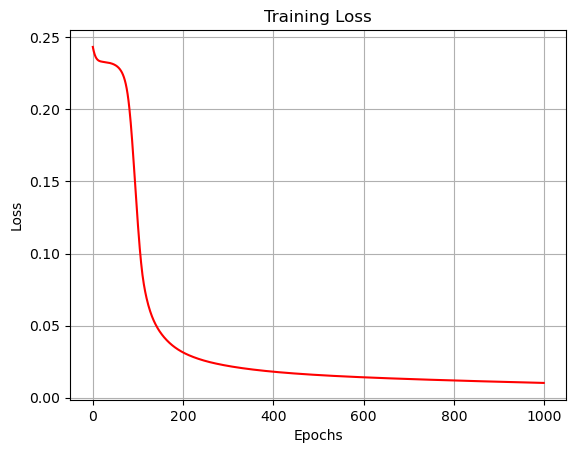

In [20]:
plt.plot(losses, color = 'r')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid()
plt.show()

In [21]:
from sklearn.metrics import accuracy_score
y_pred = ann.Predict(X_test)
y_pred_class = (y_pred > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred_class)

print(f'Accuracy = {accuracy * 100:.2f}%')

Accuracy = 97.90%


In [22]:
y_pred

array([[0.07086981],
       [0.99999829],
       [0.99984144],
       [0.04788503],
       [0.04788503],
       [1.        ],
       [1.        ],
       [0.99257872],
       [0.38660603],
       [0.04788503],
       [0.04838617],
       [0.99772599],
       [0.04788503],
       [0.94738401],
       [0.04788503],
       [0.99888679],
       [0.04788503],
       [0.04788503],
       [0.04788503],
       [0.99999987],
       [0.04788503],
       [0.04788503],
       [1.        ],
       [0.04788503],
       [0.04788503],
       [0.04788503],
       [0.04788503],
       [0.04788503],
       [0.04788503],
       [0.99999911],
       [0.04788503],
       [0.04788503],
       [0.04788503],
       [0.04788503],
       [0.04788503],
       [0.04788503],
       [0.98750261],
       [0.04788503],
       [0.99999283],
       [0.04788503],
       [0.04788503],
       [0.99995472],
       [0.04788503],
       [0.04788503],
       [0.04788503],
       [0.11590003],
       [0.04788503],
       [0.047

In [23]:
y_pred_class

array([[0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
    

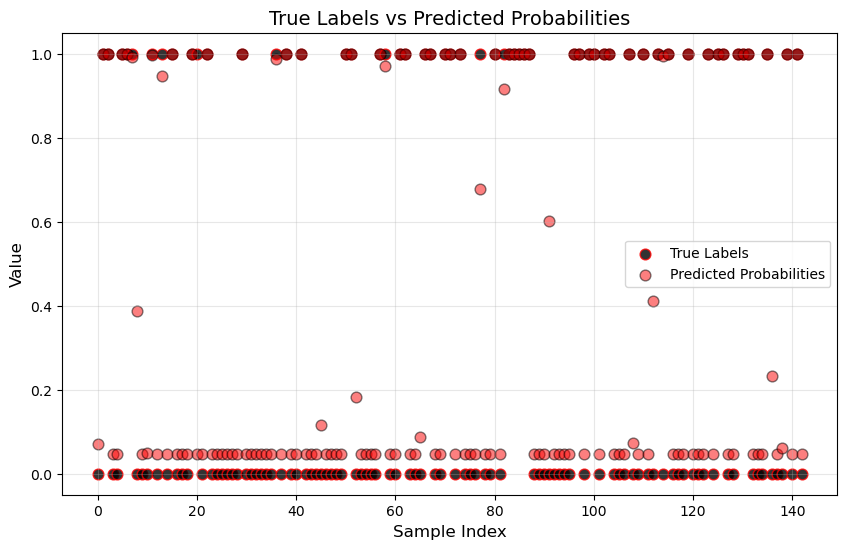

In [34]:
plt.figure(figsize=(10,6))

# True values 
plt.scatter(
    range(len(y_test)),
    y_test,
    label="True Labels",
    color="#000000",   
    edgecolors="red",
    s=60,
    alpha=0.8
)

# Predicted values 
plt.scatter(
    range(len(y_pred)),
    y_pred,
    label="Predicted Probabilities",
    color="#FA0000",  
    edgecolors="black",
    s=60,
    alpha=0.5
)

plt.xlabel("Sample Index", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.title("True Labels vs Predicted Probabilities", fontsize=14)

plt.legend()
plt.grid(alpha=0.3)

plt.show()